# Petemuan 5 - Visualisasi Data

Nama: Widya Anggara  
NIM: 230401020091  
Kelas: IF401

# Import Library dan Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = sns.load_dataset('tips')

print('Shape:', df.shape)
print('\nTipe Data:')
print(df.dtypes)

print('\n5 Data Teratas:')
print(df.head())

print('\nStatistik Deskriptif:')
print(df.describe().round(2))

Shape: (244, 7)

Tipe Data:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

5 Data Teratas:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Statistik Deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


# Bar Chart

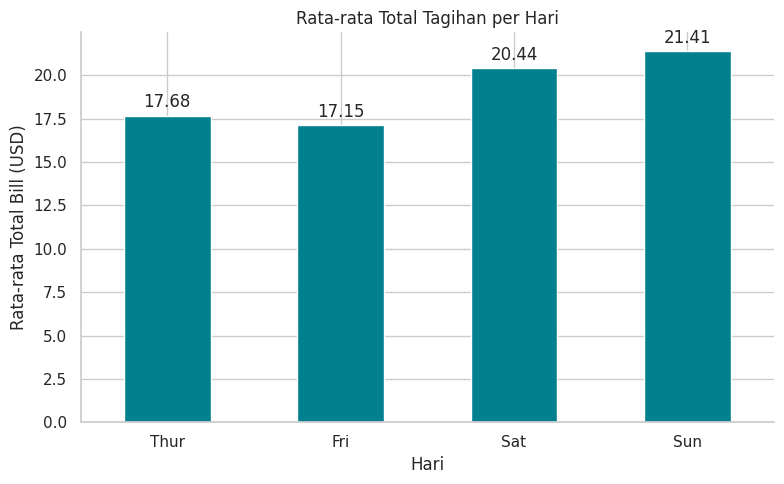

In [3]:
avg_bill_by_day = df.groupby('day', observed=False)['total_bill'].mean().round(2)
count_by_day = df['day'].value_counts()
avg_tip_by_day = df.groupby('day', observed=False)['tip'].mean().round(2)
corr_bill_tip = df[['total_bill', 'tip']].corr().loc['total_bill', 'tip']

avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

avg_by_day.plot(
    kind='bar',
    ax=ax,
    color='#028090',
    edgecolor='white'
)

ax.set_title('Rata-rata Total Tagihan per Hari')
ax.set_xlabel('Hari')
ax.set_ylabel('Rata-rata Total Bill (USD)')
ax.tick_params(axis='x', rotation=0)
ax.spines[['top', 'right']].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Insight Grafik 1 — Bar Chart Rata-rata Total Bill per Hari

**What?** Grafik bar chart menunjukkan rata-rata total tagihan pelanggan berdasarkan hari. Berdasarkan hasil visualisasi, hari Minggu memiliki rata-rata total tagihan paling tinggi, sedangkan Jumat cenderung lebih rendah dibandingkan hari lainnya.

**So what?** Hal ini menunjukkan bahwa transaksi pada akhir pekan, terutama Minggu, cenderung menghasilkan tagihan yang lebih besar. Kemungkinan pelanggan datang dalam kelompok lebih besar atau memesan lebih banyak menu pada akhir pekan.

**Now what?** Restoran dapat memberi perhatian lebih pada operasional akhir pekan, misalnya memastikan stok bahan makanan dan jumlah staf mencukupi pada hari dengan rata-rata tagihan tinggi.

# Histogram + KDE

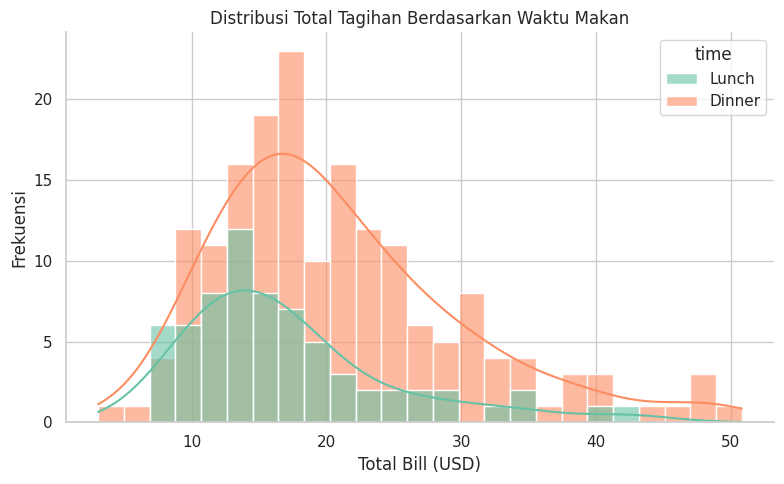

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    bins=25,
    palette='Set2',
    alpha=0.6,
    ax=ax
)

ax.set_title('Distribusi Total Tagihan Berdasarkan Waktu Makan')
ax.set_xlabel('Total Bill (USD)')
ax.set_ylabel('Frekuensi')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Insight Grafik 2 — Histogram Distribusi Total Bill

**What?** Histogram menunjukkan distribusi total tagihan pelanggan berdasarkan waktu makan, yaitu lunch dan dinner. Sebagian besar total tagihan berada pada rentang rendah hingga menengah, sedangkan hanya sedikit transaksi yang memiliki nilai tagihan sangat tinggi.

**So what?** Distribusi total_bill terlihat cenderung miring ke kanan karena terdapat beberapa tagihan bernilai besar. Hal ini berarti rata-rata tagihan dapat dipengaruhi oleh transaksi besar, sehingga median juga penting diperhatikan.

**Now what?** Analisis lanjutan dapat dilakukan dengan membandingkan nilai mean dan median total_bill untuk mengetahui apakah transaksi besar memiliki pengaruh kuat terhadap rata-rata tagihan.

# Boxplot

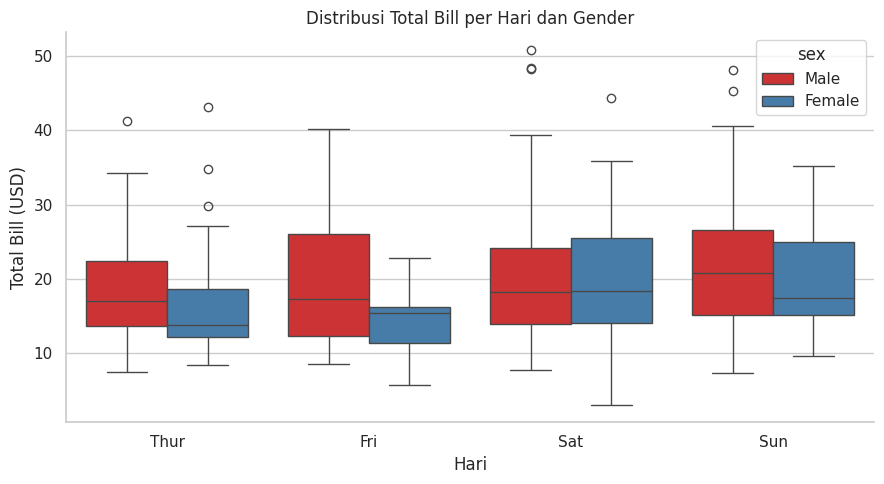

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1',
    ax=ax
)

ax.set_title('Distribusi Total Bill per Hari dan Gender')
ax.set_xlabel('Hari')
ax.set_ylabel('Total Bill (USD)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Insight Grafik 3 — Boxplot Total Bill per Hari dan Gender

**What?** Boxplot menunjukkan sebaran total_bill berdasarkan hari dan jenis kelamin pelanggan. Grafik ini memperlihatkan median, rentang antar-kuartil, serta kemungkinan outlier pada setiap kelompok.

**So what?** Beberapa hari memiliki sebaran total_bill yang lebih lebar, menandakan variasi nilai transaksi yang lebih besar. Adanya outlier menunjukkan terdapat pelanggan dengan tagihan jauh lebih tinggi dibanding transaksi umum.

**Now what?** Restoran dapat mengecek karakteristik transaksi outlier, misalnya jumlah pelanggan dalam satu meja atau waktu makan, untuk memahami penyebab tagihan tinggi tersebut.

# Scatter Plot

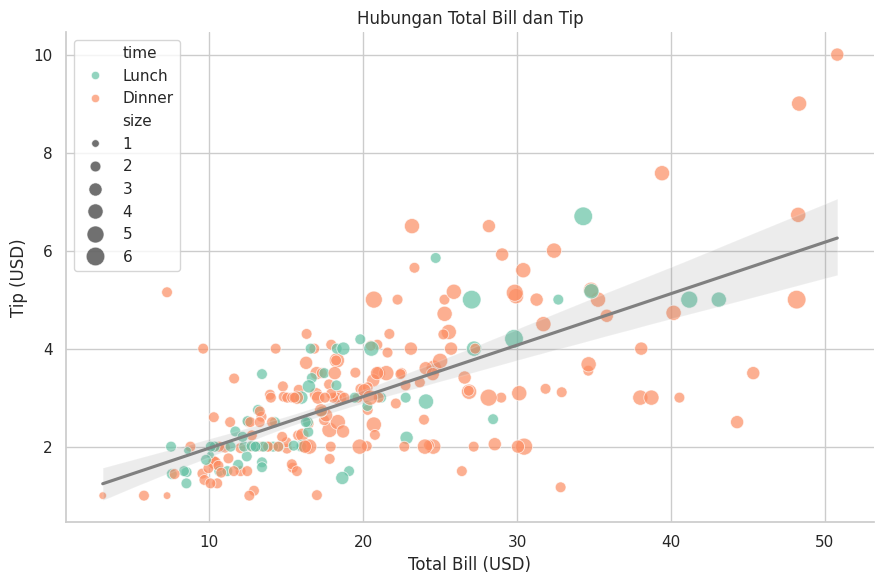

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180),
    palette='Set2',
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax
)

ax.set_title('Hubungan Total Bill dan Tip')
ax.set_xlabel('Total Bill (USD)')
ax.set_ylabel('Tip (USD)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Insight Grafik 4 — Scatter Plot Total Bill dan Tip

**What?** Scatter plot menunjukkan hubungan antara total_bill dan tip. Setiap titik merepresentasikan satu transaksi, warna menunjukkan waktu makan, dan ukuran titik menunjukkan jumlah orang dalam satu transaksi.

**So what?** Terlihat adanya hubungan positif antara total_bill dan tip. Semakin besar total tagihan, nilai tip cenderung ikut meningkat, meskipun tidak semua transaksi mengikuti pola yang sama secara sempurna.

**Now what?** Analisis lanjutan dapat dilakukan dengan menghitung korelasi antara total_bill dan tip, serta melihat apakah pola hubungan tersebut berbeda antara lunch dan dinner.

## Kesimpulan

Pada praktikum Pertemuan 5 ini, saya mempelajari visualisasi data menggunakan Matplotlib dan Seaborn. Dataset yang digunakan adalah dataset Tips, yaitu dataset transaksi restoran yang berisi informasi total tagihan, tip, hari, waktu makan, jenis kelamin pelanggan, status perokok, dan jumlah orang dalam satu transaksi.

Visualisasi yang dibuat meliputi bar chart untuk membandingkan rata-rata total tagihan per hari, histogram untuk melihat distribusi total tagihan, boxplot untuk melihat penyebaran total_bill berdasarkan hari dan gender, serta scatter plot untuk melihat hubungan antara total_bill dan tip. Dari hasil visualisasi, terlihat bahwa akhir pekan cenderung memiliki rata-rata tagihan lebih tinggi dan terdapat hubungan positif antara total_bill dan tip.